dtype('uint8')

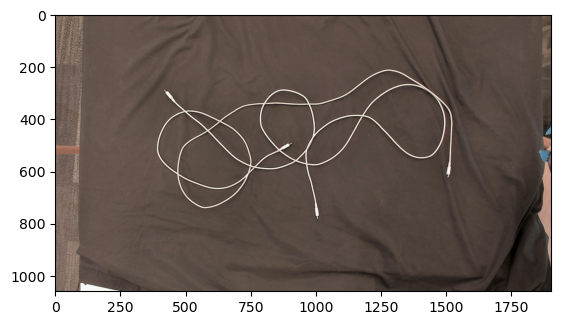

In [1]:
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
import torch

# im_frame2 = Image.open('/home/justinyu/multicable-decluttering/decluttering/scripts/test/cable_only_img_depth_pairs/intensity_image2024-06-29T18:00:38.984569.png')
# im_frame2 = Image.open("/home/justinyu/vsumedh/data/raw_images/parallel-20240711-124446.png")
# im_frame2 = Image.open("/home/justinyu/vsumedh/data/raw_images/parallel-20240730-151034.png")
im_frame2 = Image.open("/home/justinyu/vsumedh/data/raw_images/parallel-20240730-152135.png")

np_frame2 = np.array(im_frame2)

# remove alpha channel
# np_frame2 = np_frame2[0:650, :, :3]
# tt_frame2 = torch.tensor(np_frame2).to(torch.uint8)
plt.imshow(np_frame2)
np_frame2.shape
np_frame2.dtype

In [2]:
print(np_frame2.shape)
np_frame2 = np_frame2[:, 0:1800,:]

(1060, 1904, 3)


(1060, 1800, 3)


/home/justinyu/multicable-decluttering/decluttering/data/detectron2_repo/detectron2/structures/image_list.py:99: UserWarning: __floordiv__ is deprecated, and its behavior will change in a future version of pytorch. It currently rounds toward 0 (like the 'trunc' function NOT 'floor'). This results in incorrect rounding for negative values. To keep the current behavior, use torch.div(a, b, rounding_mode='trunc'), or for actual floor division, use torch.div(a, b, rounding_mode='floor').
  max_size = (max_size + (stride - 1)) // stride * stride
/home/mallika/anaconda3/envs/vsumedh-lipnew-tangential/lib/python3.8/site-packages/torch/functional.py:478: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at  /opt/conda/conda-bld/pytorch_1656352465323/work/aten/src/ATen/native/TensorShape.cpp:2894.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


Endpoint detection took 2.494340658187866 seconds


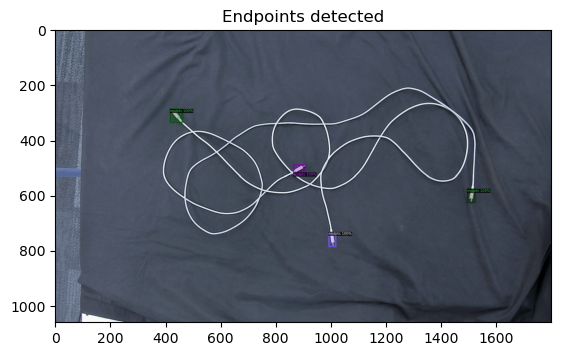

(1060, 1800, 3)
[[ 761 1006]
 [ 603 1510]
 [ 313  440]
 [ 505  886]]


<Figure size 640x480 with 0 Axes>

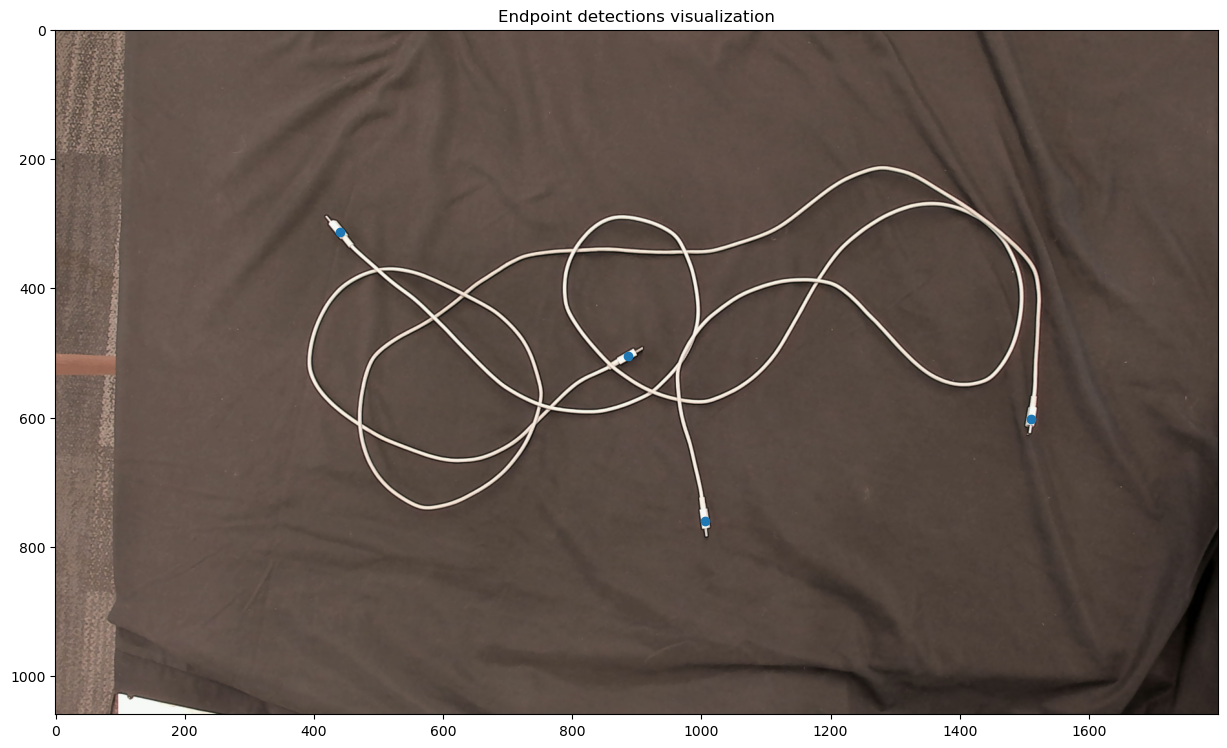

In [3]:
img = np_frame2
from decluttering.data.detectron2_repo import analysis as loop_detectron
import numpy as np 
import time

def get_endpoints(img):
    # model not used, already specified in loop_detectron
    # self.img = self.iface.take_image()
    endpoint_start = time.time()
    endpoint_boxes, out_viz = loop_detectron.predict(img, thresh=0.99, endpoints=True)
    endpoint_end = time.time()
    print("Endpoint detection took {} seconds".format(endpoint_end - endpoint_start))
    plt.clf()
    plt.imshow(out_viz)
    plt.title("Endpoints detected")
    plt.show()
    plt.imsave("/home/justinyu/multicable-decluttering/misc_images/endpoints_detected.png", out_viz)
    print(out_viz.shape)
    # show_img()

    endpoints = []
    for i, box in enumerate(endpoint_boxes):
        xmin, ymin, xmax, ymax = box
        x = (xmin + xmax)/2
        y = (ymin + ymax)/2

        # print(xmin.astype(np.int32))
        # plt.clf()
        # plt.imshow(img[ymin.astype(np.int32):ymax.astype(np.int32), xmin.astype(np.int32):xmax.astype(np.int32)])
        # plt.show()
        # plt.imsave(f"/home/justinyu/multicable-decluttering/misc_images/endpoints_crop{i}.png", img[ymin.astype(np.int32):ymax.astype(np.int32), xmin.astype(np.int32):xmax.astype(np.int32)])
        # new_yx = self.closest_valid_point(self.img.color._data, self.img.depth._data, np.array([y,x]))
        # print(x)
        # print(y)
        # endpoints.append([new_yx, new_yx])
        endpoints.append([y, x])   
    endpoints = np.array(endpoints).astype(np.int32)
    print(endpoints)
    # # (n,2,2) (num endpoints, (head point, neck point), (x,y))
    # endpoints = np.array([e for e in endpoints if self.img.depth._data[e[0][0], e[0][1]] > 0])
    # self.logger.debug("Found {} true endpoints after filtering for depth".format(len(endpoints)))

    plt.clf()
    plt.figure(figsize=(15,18))
    plt.title("Endpoint detections visualization")
    plt.imshow(img)
    if len(endpoints) > 0:
        plt.scatter(endpoints[:, 1], endpoints[:, 0])
    plt.show()
    # plt.imsave("/home/justinyu/multicable-decluttering/misc_images/endpoints_detected_with_clutter.png", img)
    # self.show_img()

    # endpoints = endpoints.astype(np.int32).reshape(-1, 2, 2)
    # # endpoint1 = endpoints[0][0]
    # # endpoint2 = endpoints[1][0]
    # self.endpoints = endpoints[:, 0, :] #np.array([endpoint1, endpoint2])
    return endpoints

print(img.shape)
endpts = get_endpoints(img)

/home/mallika/anaconda3/envs/vsumedh-lipnew-tangential/lib/python3.8/site-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.16.5 and <1.23.0 is required for this version of SciPy (detected version 1.24.3
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


Loading pretrained CLIP
Resetting zs_weight datasets/metadata/lvis_v1_clip_a+cname.npy
Inference time:  0.07680034637451172
Number of masks before filtering torch.Size([2, 1, 1060, 1800])
Area of masks before filtering tensor([ 101830, 1790930], device='cuda:0')
torch.Size([0, 1, 1060, 1800])


/home/justinyu/multicable-decluttering/decluttering/data/detectron2_repo/detectron2/structures/image_list.py:99: UserWarning: __floordiv__ is deprecated, and its behavior will change in a future version of pytorch. It currently rounds toward 0 (like the 'trunc' function NOT 'floor'). This results in incorrect rounding for negative values. To keep the current behavior, use torch.div(a, b, rounding_mode='trunc'), or for actual floor division, use torch.div(a, b, rounding_mode='floor').
  max_size = (max_size + (stride - 1)) // stride * stride


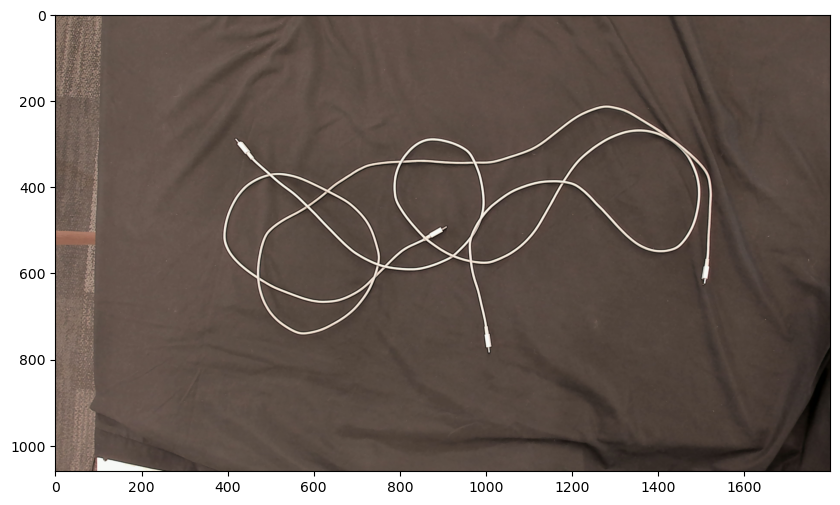

In [4]:
from decluttering.data.utils.detic_dataloader import DeticDataloader

detic = DeticDataloader()
detic.create()
detic.default_vocab()
out = detic.predict(np_frame2)
import torch
num_masks = out['masks'].shape[0]
print("Number of masks before filtering", out['masks'].shape)
print("Area of masks before filtering", torch.sum(out['masks'], dim = (1,2,3)))

def filter_mask_by_area(masks, max_area = 17000, min_area = 500):
    """
    Filter masks by area
    """
    mask_areas = torch.sum(masks, dim = (1,2,3))
    mask_areas = mask_areas.cpu().numpy()
    mask_areas = mask_areas.reshape(-1)
    masks_filtered = masks[(mask_areas < max_area) & (min_area < mask_areas)]
    return masks_filtered

filtered_areas = filter_mask_by_area(out['masks'])
print(filtered_areas.shape)
num_masks = filtered_areas.shape[0]

starting_block = filter_mask_by_area(out['masks'], max_area = 24000, min_area = 17000)
detic.visualize_output(np_frame2, filtered_areas, image_save_path=f"detic_masks/filtered_masks{time}.png")

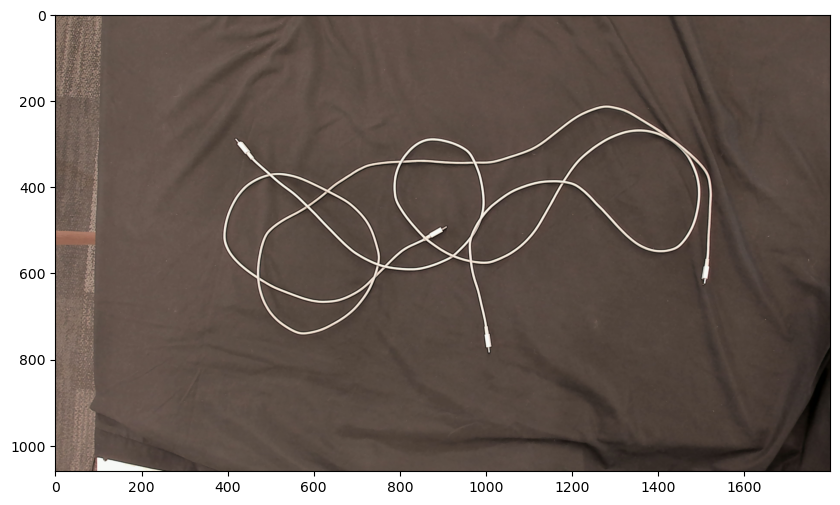

In [5]:
detic.visualize_output(np_frame2, starting_block)

In [6]:
# def combine_masks(masks):
#     """
#     Combine masks into a single mask
#     """
#     ones = torch.ones(masks[0].shape).to(masks.device)
#     combined_mask = torch.minimum(torch.sum(masks, dim = 0), ones).squeeze(0)
#     return combined_mask

# plt.imshow(combine_masks(filtered_areas).cpu().numpy())

In [7]:
# def filter_endpoint_centers(combined_mask, endpoints):
#     # Filter out endpoints that fall inside of a clutter object mask
#     # combined_mask shape is (H, W)
#     # endpoints is a list of shape (n, 2) (num endpoints, (x,y)) i.e. [[ 77 463] [279 225] [336 486] [370 352]]
#     endpoint_centers = []
#     for endpoint in endpoints:
#         y, x = endpoint
#         if combined_mask[y, x] == 0:
#             endpoint_centers.append(endpoint)
#     return endpoint_centers

# print(endpts)
# filtered_endpoint_centers = np.array(filter_endpoint_centers(combine_masks(filtered_areas), endpts))    

In [8]:

# plt.clf()
# plt.figure(figsize=(15,18))
# plt.title("Filtered Endpoint detections visualization")
# plt.imshow(img)
# if len(filtered_endpoint_centers) > 0:
#     plt.scatter(filtered_endpoint_centers[:, 1], filtered_endpoint_centers[:, 0])
# plt.show()

In [9]:
from decluttering.data.tracer.analytic_tracer.simple_uncertain_trace_single import trace

def analytic_tracer(img, point, keepout_mask=None):
        # trace from endpoint on image
        path, finished_paths = trace(img, point, exact_path_len=3, viz=False, keepout_mask=keepout_mask)
        agree_point = tuple(np.array([point[0], point[1]]).astype(np.int32))
        if path is None:
            if len(finished_paths) > 0:
                min_len_path = float('inf')
                for fp in finished_paths:
                    if len(fp) < min_len_path:
                        min_len_path = len(fp)
                for i in range(min_len_path):
                    values = np.array([list(fp[i]) for fp in finished_paths])
                    x = values[:, 0]
                    y = values[:, 1]
                    x_diff = np.max(x)-np.min(x)
                    y_diff = np.max(y)-np.min(y)
                    if x_diff < 5 and y_diff < 5:
                        agree_point = values[0]
            return agree_point, True
        return path, False



In [10]:
import colorsys
from collections import OrderedDict

def visualize_trace_solid_color(img, path, black=False, color=None):
        img = img.copy()
        def color_for_pct(pct):
            return colorsys.hsv_to_rgb(pct, 1, 1)[0] * 255, colorsys.hsv_to_rgb(pct, 1, 1)[1] * 255, colorsys.hsv_to_rgb(pct, 1, 1)[2] * 255
            # return (255*(1 - pct), 150, 255*pct) if not black else (0, 0, 0)
        def color_heatmap(pct):
            return colorsys.hsv_to_rgb(pct/3, 1, 1)[0] * 255, colorsys.hsv_to_rgb(pct/3, 1, 1)[1] * 255, colorsys.hsv_to_rgb(pct/3, 1, 1)[2] * 255
        # print(path)
        for i in range(len(path) - 1):
            
            # if path is ordered dict, use below logic
            if not isinstance(path, OrderedDict):
                pt1 = tuple(path[i].astype(int))
                pt2 = tuple(path[i+1].astype(int))
            else:
                path_keys = list(path.keys())
                pt1 = path_keys[i]
                pt2 = path_keys[i + 1]
            # print(color_for_pct(i/len(path)))

            cv2.line(img, pt1[::-1], pt2[::-1], color, 2 if not black else 5)
            # if color is not None:
            #     # print(np.asarray(cov_det)[i])
            #     cv2.line(img, pt1[::-1], pt2[::-1], color_heatmap(1-np.asarray(color)[i]), 2 if not black else 5)
            # else:
            #     cv2.line(img, pt1[::-1], pt2[::-1], color_for_pct(i/len(path)), 2 if not black else 5)
        return img

ON ENDPOINT: [ 761 1006]
FIRST STARTING PIXEL: [[ 761 1006]
 [ 733 1000]
 [ 706  996]
 [ 678  992]]
Autoregressive Tracer Using GPU
Beginning trace with 4 start points


Elapsed time for tracing:  2.316784143447876
VIT HEATMAP FOR ENDPOINT: 0


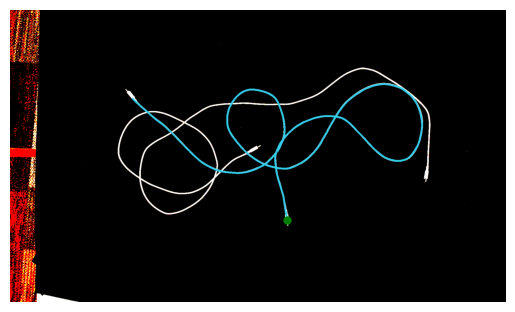

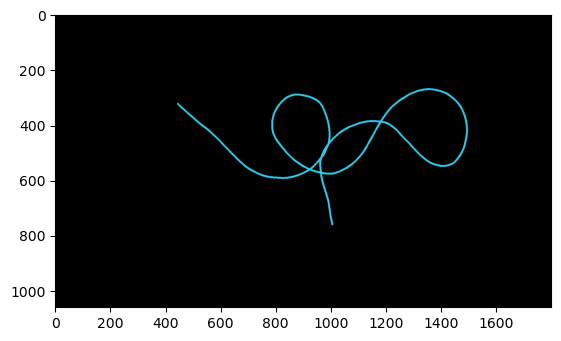

ON ENDPOINT: [ 603 1510]
FIRST STARTING PIXEL: [[ 603 1510]
 [ 576 1517]
 [ 548 1518]
 [ 520 1519]]
Autoregressive Tracer Using GPU
Beginning trace with 4 start points
Elapsed time for tracing:  1.6763370037078857
VIT HEATMAP FOR ENDPOINT: 1


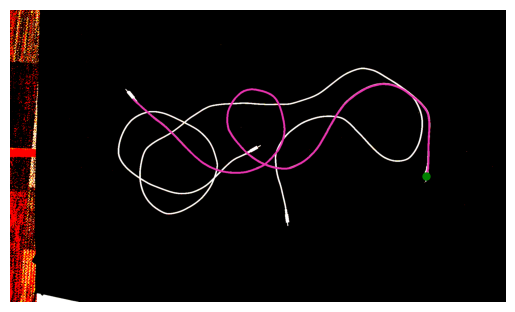

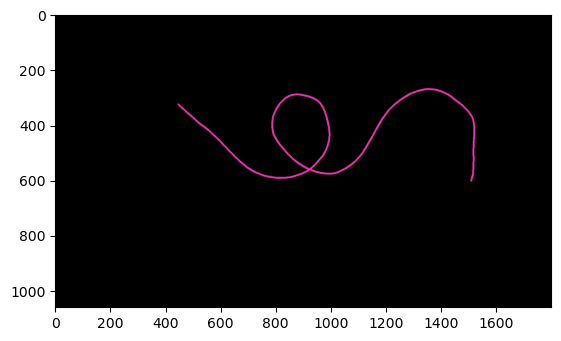

ON ENDPOINT: [313 440]
FIRST STARTING PIXEL: [[313 440]
 [331 460]
 [373 498]
 [391 518]]
Autoregressive Tracer Using GPU
Beginning trace with 4 start points
Elapsed time for tracing:  1.5835456848144531
VIT HEATMAP FOR ENDPOINT: 2


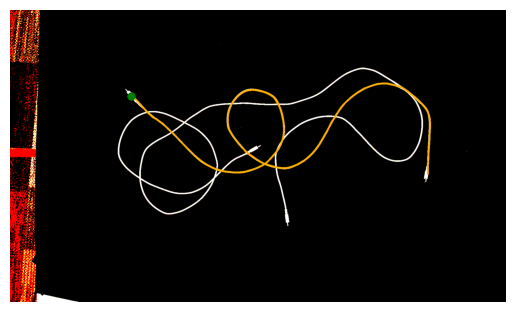

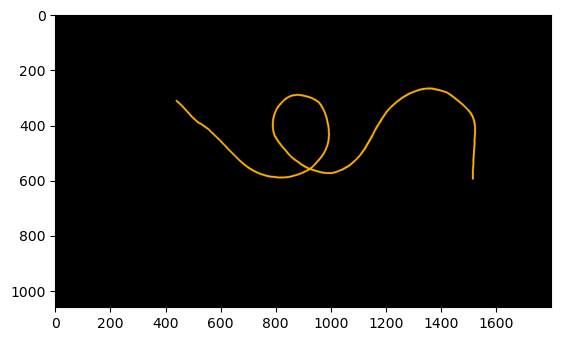

ON ENDPOINT: [505 886]
FIRST STARTING PIXEL: [[505 886]
 [520 862]
 [533 838]
 [545 813]]
Autoregressive Tracer Using GPU
Beginning trace with 4 start points
Elapsed time for tracing:  2.2463622093200684
VIT HEATMAP FOR ENDPOINT: 3


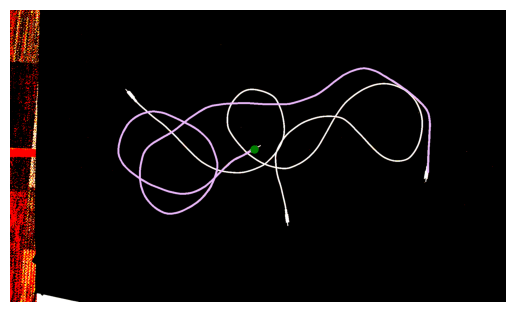

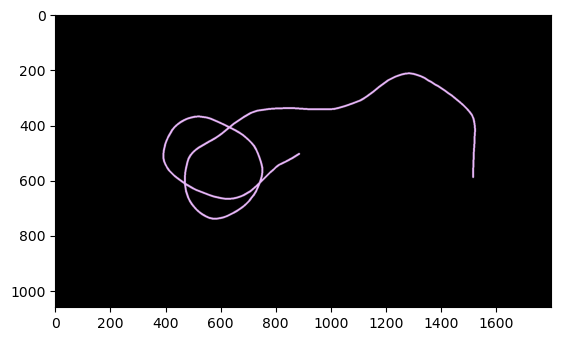

In [11]:
# random_endpt = np.random.permutation(len(endpts))[0]

BLUE_COLOR = (52, 205, 235)
MAGENTA_COLOR = (235, 52, 177)
ORANGE_COLOR = (255, 178, 0)
LILAC_COLOR = (235, 185, 252)
YELLOW_COLOR = (252, 255, 0)
TURQUOISE_COLOR = (0, 255, 188)
RED_COLOR = (255, 0, 0)
LIME_COLOR = (205, 255, 135)

colors = [BLUE_COLOR, MAGENTA_COLOR, ORANGE_COLOR, LILAC_COLOR, YELLOW_COLOR, TURQUOISE_COLOR, RED_COLOR, LIME_COLOR]
img_mask_list = []
for random_endpt in range(len(endpts)):

    print("ON ENDPOINT: " + str(np.array(endpts[random_endpt])))

    starting_pixels = analytic_tracer(img, np.array(endpts[random_endpt]), keepout_mask=None)

    print("FIRST STARTING PIXEL: " + str(np.asarray(starting_pixels[0]).astype(int)))
    # print(f"X COORD FOR ENDPOINT = {endpts[random_endpt][0]}")
    # print(f"Y COORD FOR ENDPOINT = {endpts[random_endpt][1]}")


    # TRACER + HEATMAP
    from decluttering.data.tracer.tusk_pipeline.tracer import Tracer
    import datetime
    from decluttering.data.utils.tracer_dataloader import TracerDataloader
    time = datetime.datetime.now().strftime("%Y-%m-%d-%H-%M-%S")
    tracer = TracerDataloader()

    out = tracer.predict(img, np.asarray(starting_pixels[0]).astype(int), endpoints=endpts)
    trace_path = out["trace"]
    heatmaps = out["heatmaps"]
    plt.clf()

    # plt.imshow(tracer.tracer.visualize_path(img, np.array(trace_path)))
    plt.axis('off')
    # plt.imsave(f"/home/justinyu/multicable-decluttering/decluttering/scripts/test/cable_uncertainty/path_certainty_{time}_trace.png", tracer.tracer.visualize_path(img, np.array(trace)))

    # Veena: heatmap for ViT

    vit_conf_path = out["vit"]
    print("VIT HEATMAP FOR ENDPOINT: " + str(random_endpt))
    tracer_viz_path = tracer.tracer.visualize_path(img, np.array(trace_path), color=vit_conf_path)
    # plt.imshow(tracer_viz_path)
    # plt.axis('off')
    # plt.show()

    ############# APPLYING IMAGE THRESHOLD TO MAKE BLACK AND WHITE MASK ####### 
    import cv2

    _, img_thresh = cv2.threshold(img, 127, 255, cv2.THRESH_BINARY)
    # plt.imshow(img_thresh)
    # plt.show()

    img_thresh_with_path = visualize_trace_solid_color(img_thresh, trace_path, color = colors[random_endpt], black = True)
    plt.imshow(img_thresh_with_path)
    plt.plot(endpts[random_endpt][1], endpts[random_endpt][0], "og", markersize=5)
    plt.show()

    all_black_img = np.zeros(img.shape, dtype=np.uint8)
    img_mask_only = visualize_trace_solid_color(all_black_img, trace_path, color = colors[random_endpt], black = True)
    img_mask_list.append(img_mask_only)
    plt.imshow(img_mask_only)
    # plt.imsave(img_mask_only)
    plt.imsave(f"/home/justinyu/multicable-decluttering/decluttering/scripts/test/cable_uncertainty/img_mask_{time}_trace.png", img_mask_only)
    plt.show()
    # plt.imsave(f"/home/justinyu/multicable-decluttering/decluttering/scripts/test/cable_uncertainty/path_certainty_{time}_vit.png", tracer.tracer.visualize_path(img, np.array(trace), color=vit_conf_path))

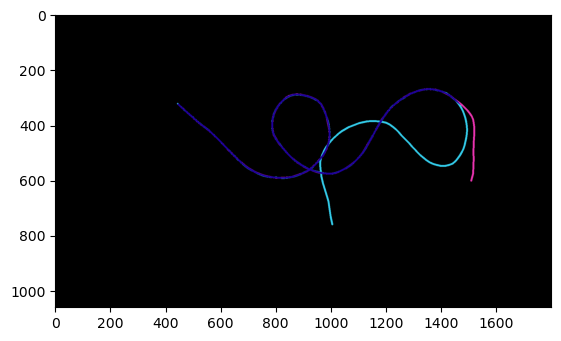

In [12]:
# adding blue and lilac masks together
blue_magenta = img_mask_list[0] + img_mask_list[1]
plt.imshow(blue_magenta)
plt.show()

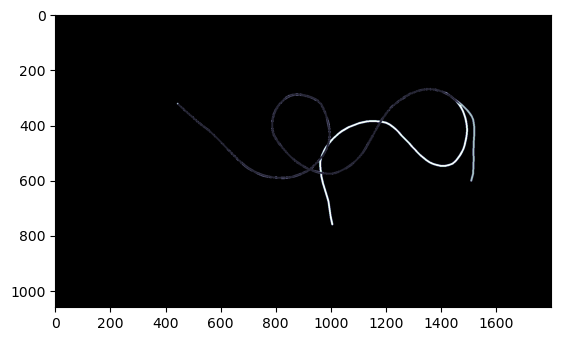

NAVY_COLOR = [287 257 412]


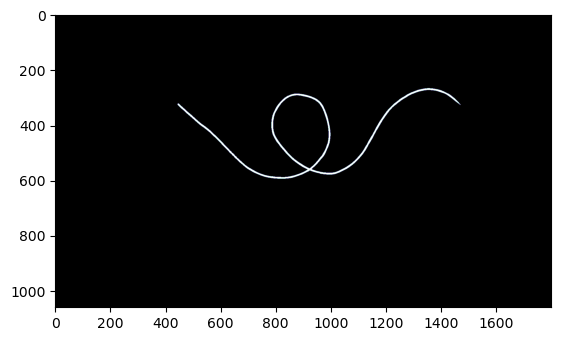

In [128]:
from matplotlib import cm

grayscale = cv2.cvtColor(blue_magenta, cv2.COLOR_RGB2GRAY)
plt.imshow(grayscale, cmap=cm.bone)
plt.show()

# print(blue_magenta.shape)

# BLUE_COLOR = (52, 205, 235)
# MAGENTA_COLOR = (235, 52, 177)

NAVY_COLOR = np.add(BLUE_COLOR, MAGENTA_COLOR)
print("NAVY_COLOR = " + str(NAVY_COLOR))

# layered_thresh = cv2.inRange(img, (255, 0, 0), (100, 0, 0))

# layered_thresh = cv2.inRange(blue_magenta, NAVY_COLOR, NAVY_COLOR)

# TODO: 100 is hardcoded
_, layered_thresh = cv2.threshold(grayscale, 100, 255, cv2.THRESH_TOZERO_INV)
# layered_thresh = cv2.bitwise_not(layered_thresh)
plt.imshow(layered_thresh, cmap=cm.bone)
plt.show()

In [13]:
def neighbors(x, y, img):
    neighs = []
    if x + 1 < len(img.shape[0]):
        neighs.append((x + 1, y, img[x + 1][y]))
    if x - 1 >= 0:
        neighs.append(x - 1, y, img[x - 1][y])
    if y + 1 < len(img.shape[1]):
        neighs.append((x, y + 1, img[x][y + 1]))
    if y - 1 >= 0:
        neighs.append((x, y - 1, img[x][y - 1]))

In [138]:
# binary_thresh = layered_thresh // 255

(array([], dtype=int64), array([], dtype=int64))


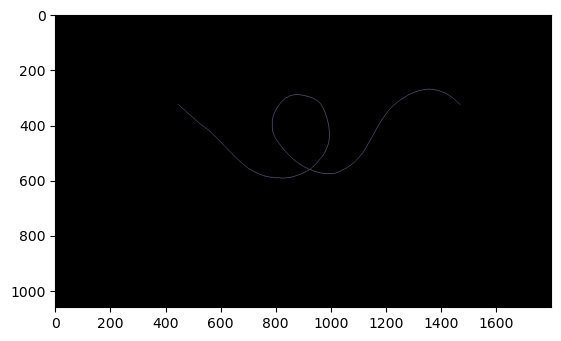

array([1, 1, 1, ..., 1, 1, 1], dtype=uint8)

In [153]:
from skimage.morphology import skeletonize
# print(np.nonzero(layered_thresh))
skel_img = skeletonize(layered_thresh, method = "lee")
plt.imshow(skel_img, cmap=cm.bone)
plt.show()

# convert to binary
bin_img = skel_img // 28
bin_img[np.nonzero(bin_img)]

np.min(neighbor_sum) = 0
np.max(neighbor_sum) = 5
np.min(middle_ones_neighbor_sum) = 0
np.max(middle_ones_neighbor_sum) = 4
points_of_interest = array([[ 447,  326],
       [1470,  327]])


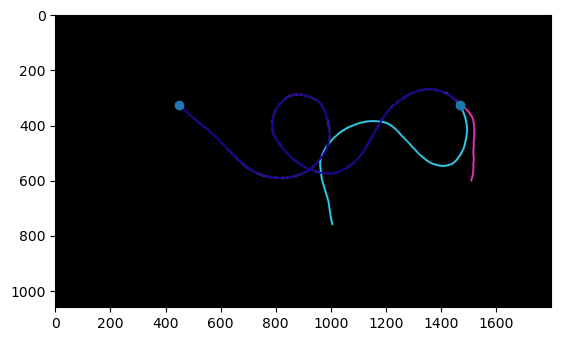

In [220]:
from scipy.ndimage import convolve
kernel = np.array([[1, 1, 1],
       [1, 1, 1],
       [1, 1, 1]])

neighbor_sum = convolve(bin_img, kernel, mode='constant')
print(f"{np.min(neighbor_sum) = }")
print(f"{np.max(neighbor_sum) = }")


middle_ones_neighbor_sum = np.multiply(neighbor_sum, bin_img) # if 1 in center of 3x3, sums up all neighbors including center pixel, for each pixel on image
print(f"{np.min(middle_ones_neighbor_sum) = }")
print(f"{np.max(middle_ones_neighbor_sum) = }")

# visualize middle_ones_neighbor_sum
# bright_img = middle_ones_neighbor_sum * 70
plt.imshow(blue_magenta, cmap=cm.bone)
# plt.show()

# neighbor_sum[np.nonzero(bin_img)].shape

# endpoint1, endpoint2 = np.argwhere(middle_ones_neighbor_sum == 2)

# print(np.argwhere(middle_ones_neighbor_sum == 2))
points_of_interest = np.flip(np.argwhere(middle_ones_neighbor_sum == 2), axis = 1)
print(f"{points_of_interest = }")
# print(points_of_interest.T)
# print(np.nonzero(middle_ones_neighbor_sum == 2))

plt.scatter(points_of_interest.T[0], points_of_interest.T[1])
# plt.plot(endpoint1[1], endpoint1[0], "og", markersize=5)
# plt.plot(endpoint2[1], endpoint2[0], "og", markersize=5)
plt.show()

# np.nonzero(middle_ones_neighbor_sum == 4)

# fig, ax = plt.subplots(figsize=(20, 4))
# n = np.max(middle_ones_neighbor_sum)
# bins = np.arange(start=-0.5, stop=(n+1), step=1)
# _ = ax.hist(middle_ones_neighbor_sum, bins=bins, edgecolor='k')
# ax.set_xticks(np.arange(n+1))
# plt.show()

[1470.  327.]


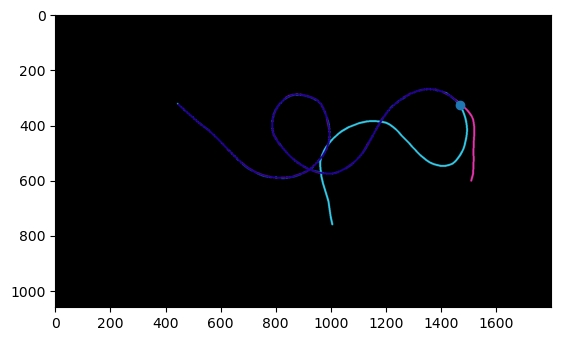

In [244]:
import math
divergence_pts = np.empty([0, 0])

# print(endpts)
for poi in points_of_interest:
    close_to_endpt = False
    for glob_endpt in np.flip(endpts, axis = 1):
        # print(f"{poi = }, {glob_endpt = }, dist = {np.linalg.norm(glob_endpt - poi)}")
        if np.linalg.norm(glob_endpt - poi) <= 20:
            close_to_endpt = True
    if not close_to_endpt:
        divergence_pts = np.append(divergence_pts, poi)

print(divergence_pts)
plt.imshow(blue_magenta)
plt.scatter(divergence_pts.T[0], divergence_pts.T[1])
plt.show()

In [70]:
x = np.random.randint(low=0,high=100,size=(1, 2 ,3) )
print(x)

print("******")

print(x[:, :, 0])
print(x[:, :, 0].shape)

[[[61 35 58]
  [16 77 66]]]
******
[[61 16]]
(1, 2)


In [84]:
# TODO: put into loop for each pair of masks (for now just doing mask 1 (magenta) and mask 2 (cyan))

# BLUE_COLOR = (52, 205, 235)
# MAGENTA_COLOR = (235, 52, 177)


skel_img.shape
print("SKEL IMG: " + str(np.nonzero(skel_img)))
print(skel_img.shape)

skel_r_only = skel_img[:, :, 0]

# skel_r_only.shape

print("SKEL R ONLY: ")
print(np.nonzero(skel_r_only))

print("ONLY NAVY VALS")

print(skel_r_only[skel_r_only == NAVY_COLOR[0]])

print("CONV TO ONE:")

print(np.argwhere(skel_r_only // NAVY_COLOR[0]))

# color_num = {BLUE_COLOR: 0, MAGENTA_COLOR: 0, NAVY_COLOR: 1}
# endpt_detection_array = np.zeros(skel_img.shape[0], skel_img.shape[1], 1)





# # comb_color = np.add(colors[0], colors[1]) # tuple of navy color
# x_length = skel_img.shape[0]
# y_length = skel_img.shape[1]

# points_of_interest = []
# # for each coord in img
# print('entering')





# for x in range(x_length):
#     for y in range(y_length):
#         rgb_xy = img[x][y]
#         print(f"{rgb_xy = }")
#         print(f"{comb_color = }")
#         if not np.array_equal(rgb_xy, np.zeros(3)):
#             count = 0
#             for neigh in neighbors(x, y, skel_img):
#                 nx, ny, n_color = neigh
#                 if n_color != 0:
#                     count += 1
#             if count == 2:
#                 points_of_interest.append((x, y, rgb_xy))

# print(points_of_interest)

NAVY_COLOR = [287 257 412]
SKEL IMG: (array([271, 271, 271, ..., 759, 760, 761]), array([1350, 1351, 1352, ..., 1006, 1006, 1006]), array([1, 1, 1, ..., 1, 1, 1]))
(1060, 1800, 3)
SKEL R ONLY: 
(array([], dtype=int64), array([], dtype=int64))
ONLY NAVY VALS
[]
CONV TO ONE:
[]


Autoregressive Tracer Using GPU
Beginning trace with 4 start points
Elapsed time for tracing:  2.2465453147888184


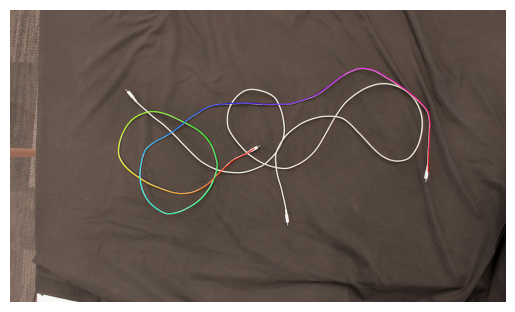

In [ ]:
# COPIED

# from decluttering.data.tracer.tusk_pipeline.tracer import Tracer
# import datetime
# from decluttering.data.utils.tracer_dataloader import TracerDataloader
# time = datetime.datetime.now().strftime("%Y-%m-%d-%H-%M-%S")
# tracer = TracerDataloader()
# # print(np.asarray(starting_pixels[0]).astype(int))

# # replace run_tracer_with_transform -> tracer.predict
# out = tracer.predict(img, np.asarray(starting_pixels[0]).astype(int), endpoints=endpts)
# # print(trace)
# trace = out["trace"]
# heatmaps = out["heatmaps"]

# plt.imshow(tracer.tracer.visualize_path(img, np.array(trace)))
# plt.axis('off')
# plt.imsave(f"/home/justinyu/multicable-decluttering/decluttering/scripts/test/cable_uncertainty/path_certainty_{time}_trace.png", tracer.tracer.visualize_path(img, np.array(trace)))


[0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 1.20500990e-05 6.76553755e-05 7.04041868e-03 4.98831039e-03
 2.56503979e-03 1.22874631e-02 2.27614250e-02 2.83619583e-01
 8.95432711e-01 5.44800341e-01 2.45141327e-01 6.51659351e-03
 8.24230374e-04 8.25550815e-05 3.04149180e-05 1.84396031e-05
 1.91503459e-05 3.33967619e-05 3.37492274e-05 6.36747282e-05
 4.20266842e-05 6.62773964e-05 5.86770984e-05 5.48591815e-05
 4.42996097e-05 8.88096838e-05 2.03430891e-01 2.23876193e-01
 3.41059029e-01 2.85840183e-01 1.49682194e-01 8.93451214e-01
 1.01644851e-04 9.70818874e-05 1.36917879e-04 7.72702449e-04
 1.01131643e-03 5.21289068e-04 3.95971038e-05 3.45051194e-05
 4.76199857e-05 4.73604850e-05 3.49316942e-05 2.24225205e-05
 1.95873181e-05 2.30707083e-05 1.76486828e-05 2.29103953e-05
 2.16473200e-05 1.35292403e-05 4.71432257e-04 3.45581025e-03
 4.04140819e-03 2.58490141e-03 4.92340066e-02 2.82572280e-03
 5.34394290e-04 1.74243687e-04 9.67006781e-05 6.19723141e-05
 9.45702341e-05 1.409137

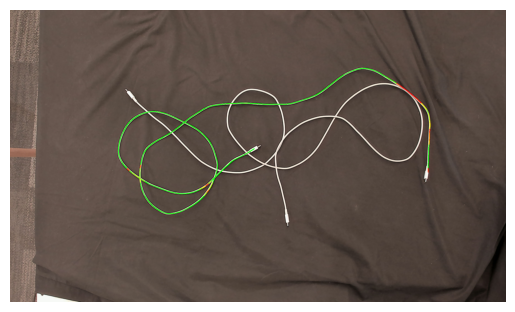

In [ ]:
# COPIED

# Veena: heatmap for ViT

# vit_conf_path = [0, 0, 0, 0] + out["vit"]
# vit_conf_path = out["vit"]
# print(vit_conf_path)
# # vit_conf_path = [(v - min(vit_conf_path))/(max(vit_conf_path) - min(vit_conf_path)) for v in vit_conf_path]
# print(len(vit_conf_path))
# # print(vit_conf_path.mean())
# plt.imshow(tracer.tracer.visualize_path(img, np.array(trace), color=vit_conf_path))
# plt.axis('off')
# plt.imsave(f"/home/justinyu/multicable-decluttering/decluttering/scripts/test/cable_uncertainty/path_certainty_{time}_vit.png", tracer.tracer.visualize_path(img, np.array(trace), color=vit_conf_path))